# California and Ontario Housing Data — Data Sourcing and EDA

## Objective

This notebook collects real housing data from California and Ontario using three source types:

1. CSV
2. Web API
3. Relational Database

The collected data will be inspected using basic exploratory data analysis, including summary statistics and visualizations.

## 1. California Housing Data — CSV Source

The California Housing Dataset is used as the primary dataset for the linear regression model.

The dataset contains housing-related predictors such as median income, house age, average rooms, population, latitude, and longitude. The target variable is median house value.

In [127]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

In [128]:
california = fetch_california_housing(as_frame=True)

california_df = california.frame

california_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [129]:
#I Saved it to data/raw/
california_path = "../data/raw/california_housing.csv"

california_df.to_csv(california_path, index=False)

print(f"California housing data saved to: {california_path}")

California housing data saved to: ../data/raw/california_housing.csv


In [130]:
# I want to Verify
california_csv = pd.read_csv(california_path)

print("Shape:", california_csv.shape)
print("\nColumns:")
print(california_csv.columns.tolist())

Shape: (20640, 9)

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


## 2. Neon PostgreSQL Database Connection

Neon PostgreSQL is used as the relational database source for this project.

The database credentials are stored in a local `.env` file and are not included in the Git repository.

In [131]:
import os
from dotenv import load_dotenv
import psycopg2

load_dotenv()

DATABASE_URL = os.getenv("DATABASE_URL")

if DATABASE_URL is None:
    raise ValueError("DATABASE_URL was not found in the .env file.")

print("Database URL loaded successfully.")

Database URL loaded successfully.


In [132]:
connection = psycopg2.connect(DATABASE_URL)

print("Successfully connected to Neon PostgreSQL!")

connection.close()

Successfully connected to Neon PostgreSQL!


### Load California Housing Data into PostgreSQL

The California Housing Dataset is loaded into a relational PostgreSQL table so that the project demonstrates database-based data ingestion and SQL querying.

In [133]:
from sqlalchemy import create_engine
from sqlalchemy.engine import make_url

sqlalchemy_url = make_url(DATABASE_URL).set(drivername="postgresql+psycopg2")
engine = create_engine(sqlalchemy_url)

In [134]:
california_df.to_sql(
    "california_housing",
    engine,
    if_exists="replace",
    index=False
)

print("California housing data loaded into Neon PostgreSQL.")

California housing data loaded into Neon PostgreSQL.


##  I want to Prove that we're actually using SQL
(Note: Later we'll add Ontario to Neon)

In [135]:
query = """
SELECT *
FROM california_housing
LIMIT 5;
"""

california_from_db = pd.read_sql_query(query, engine)

california_from_db

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



### SQL Data Selection and Filtering

To demonstrate relational database querying, we retrieve selected
California housing columns from Neon PostgreSQL.

The SQL query uses a WHERE condition to select observations with
median income greater than or equal to 5. The results are sorted
by median income in descending order.


In [136]:

from sqlalchemy import text

# Select and filter California housing records using SQL

query = text("""
    SELECT "MedInc", "MedHouseVal"
    FROM california_housing
    WHERE "MedInc" >= 5
    ORDER BY "MedInc" DESC
    LIMIT 10;
""")

with engine.connect() as connection:
    filtered_california = pd.read_sql_query(
        query,
        connection
    )

filtered_california


,MedInc,MedHouseVal
0,15.0001,5.00001
1,15.0001,5.00001
2,15.0001,5.00001
3,15.0001,5.00001
4,15.0001,3.50000
5,15.0001,5.00001
6,15.0001,5.00001
7,15.0001,5.00001
8,15.0001,5.00001
9,15.0001,5.00001


In [183]:

# Verify that SQL filtering worked correctly

print("Returned records:", len(filtered_california))

print(
    "All median income values >= 5:",
    (filtered_california["MedInc"] >= 5).all()
)


Returned records: 10
All median income values >= 5: True


## 3. Ontario Housing Data — Statistics Canada API

Ontario housing data is collected through the Statistics Canada Web Data Service API.

The project uses Statistics Canada Table 18-10-0205-01, New housing price index, monthly. The table provides monthly housing price index data for Canada, provinces and territories, and selected census metropolitan areas.

The Statistics Canada API is accessed programmatically using Python requests.

In [137]:
# I Imported the required libraries
import requests
import zipfile
import io
import os
import pandas as pd

### 3.1 Access the Statistics Canada Web Data Service

The Web Data Service provides programmatic access to Statistics Canada data.

The Product ID (PID) for Table 18-10-0205-01 is 1810020501.

In [138]:
statcan_api_url = (
    "https://www150.statcan.gc.ca/t1/wds/rest/"
    "getFullTableDownloadCSV/18100205/en"
)

print(statcan_api_url)

https://www150.statcan.gc.ca/t1/wds/rest/getFullTableDownloadCSV/18100205/en


In [139]:
# Call the API using requests
response = requests.get(statcan_api_url, timeout=60)

print("Status code:", response.status_code)

Status code: 200


In [140]:
# Before Going forward i wanted to Read the API response
api_result = response.json()

api_result

{'status': 'SUCCESS',
 'object': 'https://www150.statcan.gc.ca/n1/tbl/csv/18100205-eng.zip'}

Great We can  see a JSON response containing a download URL from above reasult.

In [141]:
# i want to Extract the download URL
download_url = api_result["object"]

print("Download URL received from Statistics Canada API:")
print(download_url)

Download URL received from Statistics Canada API:
https://www150.statcan.gc.ca/n1/tbl/csv/18100205-eng.zip


In [142]:
# Now Download the data with requests
data_response = requests.get(download_url, timeout=120)

print("Download status code:", data_response.status_code)

Download status code: 200


Great we can see our status code which is `200` which is a success code.

In [143]:
# Let's save the downloaded ZIP file under data/raw/
ontario_zip_path = "../data/raw/statcan_nhpi_1810020501.zip"

with open(ontario_zip_path, "wb") as file:
    file.write(data_response.content)

print(f"Statistics Canada data saved to: {ontario_zip_path}")

Statistics Canada data saved to: ../data/raw/statcan_nhpi_1810020501.zip


In [144]:
# i want to Extract the Statistics Canada files Programatically

with zipfile.ZipFile(io.BytesIO(data_response.content)) as zip_file:
    zip_file.extractall("../data/raw/statcan_nhpi")

In [145]:
os.listdir("../data/raw/statcan_nhpi")

['18100205.csv', '18100205_MetaData.csv']

## Read the Ontario API data

I Want  first inspect the data before filtering it. I Did not load it into Neon yet... first I need to understand its columns.

## 4. Inspect Ontario Housing Data

The Statistics Canada API returned the full New Housing Price Index table.

The main CSV file is loaded into Pandas and inspected before selecting the Ontario records needed for this project.

In [146]:
ontario_raw = pd.read_csv(
    "../data/raw/statcan_nhpi/18100205.csv"
)

print("Shape:", ontario_raw.shape)

ontario_raw.head()

Shape: (65760, 15)


,REF_DATE,GEO,DGUID,New housing price indexes,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1981-01,Canada,2016A000011124,Total (house and land),"Index, 201612=100",347,units,0,v111955442,1.1,38.2,NaN,NaN,NaN,1
1,1981-01,Canada,2016A000011124,House only,"Index, 201612=100",347,units,0,v111955443,1.2,36.1,NaN,NaN,NaN,1
2,1981-01,Canada,2016A000011124,Land only,"Index, 201612=100",347,units,0,v111955444,1.3,40.6,E,NaN,NaN,1
3,1981-01,Atlantic Region,2016A00011,Total (house and land),"Index, 201612=100",347,units,0,v111955445,2.1,NaN,..,NaN,NaN,1
4,1981-01,Atlantic Region,2016A00011,House only,"Index, 201612=100",347,units,0,v111955446,2.2,NaN,..,NaN,NaN,1


In [147]:
print("Columns:")
print(ontario_raw.columns.tolist())

Columns:
['REF_DATE', 'GEO', 'DGUID', 'New housing price indexes', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']


In [148]:
ontario_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 65760 entries, 0 to 65759
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   REF_DATE                   65760 non-null  str    
 1   GEO                        65760 non-null  str    
 2   DGUID                      64116 non-null  str    
 3   New housing price indexes  65760 non-null  str    
 4   UOM                        65760 non-null  str    
 5   UOM_ID                     65760 non-null  int64  
 6   SCALAR_FACTOR              65760 non-null  str    
 7   SCALAR_ID                  65760 non-null  int64  
 8   VECTOR                     65760 non-null  str    
 9   COORDINATE                 65760 non-null  float64
 10  VALUE                      54934 non-null  float64
 11  STATUS                     29412 non-null  str    
 12  SYMBOL                     0 non-null      float64
 13  TERMINATED                 0 non-null      float64
 14  D

In [149]:
ontario_raw.describe(include="all")

,REF_DATE,GEO,DGUID,New housing price indexes,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
count,65760,65760,64116,65760,65760,65760.0,65760,65760.0,65760,65760.000000,54934.000000,29412,0.0,0.0,65760.0
unique,548,40,39,3,1,NaN,1,NaN,120,NaN,NaN,3,NaN,NaN,NaN
top,1981-01,Canada,2016A000011124,Total (house and land),"Index, 201612=100",NaN,units,NaN,v111955442,NaN,NaN,E,NaN,NaN,NaN
freq,120,1644,1644,21920,65760,NaN,65760,NaN,548,NaN,NaN,18586,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,347.0,NaN,0.0,NaN,20.700000,80.385939,NaN,NaN,NaN,1.0
std,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,11.543773,29.591007,NaN,NaN,NaN,0.0
min,NaN,NaN,NaN,NaN,NaN,347.0,NaN,0.0,NaN,1.100000,16.700000,NaN,NaN,NaN,1.0
25%,NaN,NaN,NaN,NaN,NaN,347.0,NaN,0.0,NaN,10.900000,54.500000,NaN,NaN,NaN,1.0
50%,NaN,NaN,NaN,NaN,NaN,347.0,NaN,0.0,NaN,20.700000,85.800000,NaN,NaN,NaN,1.0
75%,NaN,NaN,NaN,NaN,NaN,347.0,NaN,0.0,NaN,30.500000,100.300000,NaN,NaN,NaN,1.0


In [150]:
# Because we need Ontario, let's see exactly how Statistics Canada names the geography.
ontario_raw["GEO"].unique()

<StringArray>
[                                             'Canada',
                                     'Atlantic Region',
                           'Newfoundland and Labrador',
               'St. John's, Newfoundland and Labrador',
                                'Prince Edward Island',
                 'Charlottetown, Prince Edward Island',
                                         'Nova Scotia',
                                'Halifax, Nova Scotia',
                                       'New Brunswick',
 'Saint John, Fredericton, and Moncton, New Brunswick',
                                              'Quebec',
                                      'Québec, Quebec',
                                  'Sherbrooke, Quebec',
                              'Trois-Rivières, Quebec',
                                    'Montréal, Quebec',
        'Ottawa-Gatineau, Quebec part, Ontario/Quebec',
                                             'Ontario',
       'Ottawa-Gatineau, Ontario p

In [151]:
# Statistics Canada tables can contain multiple types of observations. Let's inspect the categorical columns.
for column in ontario_raw.select_dtypes(include="object").columns:
    print("\n", column)
    print(ontario_raw[column].dropna().unique()[:20])


 REF_DATE
<StringArray>
['1981-01', '1981-02', '1981-03', '1981-04', '1981-05', '1981-06', '1981-07',
 '1981-08', '1981-09', '1981-10', '1981-11', '1981-12', '1982-01', '1982-02',
 '1982-03', '1982-04', '1982-05', '1982-06', '1982-07', '1982-08']
Length: 20, dtype: str

 GEO
<StringArray>
[                                             'Canada',
                                     'Atlantic Region',
                           'Newfoundland and Labrador',
               'St. John's, Newfoundland and Labrador',
                                'Prince Edward Island',
                 'Charlottetown, Prince Edward Island',
                                         'Nova Scotia',
                                'Halifax, Nova Scotia',
                                       'New Brunswick',
 'Saint John, Fredericton, and Moncton, New Brunswick',
                                              'Quebec',
                                      'Québec, Quebec',
                                  'Sh

C:\Users\Ubaid\AppData\Local\Temp\ipykernel_17068\54311772.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in ontario_raw.select_dtypes(include="object").columns:


In [152]:
metadata = pd.read_csv(
    "../data/raw/statcan_nhpi/18100205_MetaData.csv"
)

print("Shape:", metadata.shape)

metadata.head()

Shape: (85, 10)


,Cube Title,Product Id,CANSIM Id,URL,Cube Notes,Archive Status,Frequency,Start Reference Period,End Reference Period,Total number of dimensions
"New housing price index, monthly",18100205,327-0056,https://www150.statcan.gc.ca/t1/tbl1/en/tv.act...,1;2;3;13;14,CURRENT - a cube available to the public and t...,Monthly,1981-01-01,2026-08-01,2.0,NaN
Dimension ID,Dimension name,Dimension Notes,Dimension Definitions,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Geography,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,New housing price indexes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dimension ID,Member Name,Classification Code,Member ID,Parent Member ID,Terminated,Member Notes,Member Definitions,NaN,NaN,NaN


In [153]:
metadata.columns.tolist()

['Cube Title',
 'Product Id',
 'CANSIM Id',
 'URL',
 'Cube Notes',
 'Archive Status',
 'Frequency',
 'Start Reference Period',
 'End Reference Period',
 'Total number of dimensions']

In [154]:
ontario_raw.shape

(65760, 15)

In [155]:
ontario_raw.columns.tolist()

['REF_DATE',
 'GEO',
 'DGUID',
 'New housing price indexes',
 'UOM',
 'UOM_ID',
 'SCALAR_FACTOR',
 'SCALAR_ID',
 'VECTOR',
 'COORDINATE',
 'VALUE',
 'STATUS',
 'SYMBOL',
 'TERMINATED',
 'DECIMALS']

In [156]:
ontario_raw["GEO"].unique()

<StringArray>
[                                             'Canada',
                                     'Atlantic Region',
                           'Newfoundland and Labrador',
               'St. John's, Newfoundland and Labrador',
                                'Prince Edward Island',
                 'Charlottetown, Prince Edward Island',
                                         'Nova Scotia',
                                'Halifax, Nova Scotia',
                                       'New Brunswick',
 'Saint John, Fredericton, and Moncton, New Brunswick',
                                              'Quebec',
                                      'Québec, Quebec',
                                  'Sherbrooke, Quebec',
                              'Trois-Rivières, Quebec',
                                    'Montréal, Quebec',
        'Ottawa-Gatineau, Quebec part, Ontario/Quebec',
                                             'Ontario',
       'Ottawa-Gatineau, Ontario p

In [157]:
metadata.head()

,Cube Title,Product Id,CANSIM Id,URL,Cube Notes,Archive Status,Frequency,Start Reference Period,End Reference Period,Total number of dimensions
"New housing price index, monthly",18100205,327-0056,https://www150.statcan.gc.ca/t1/tbl1/en/tv.act...,1;2;3;13;14,CURRENT - a cube available to the public and t...,Monthly,1981-01-01,2026-08-01,2.0,NaN
Dimension ID,Dimension name,Dimension Notes,Dimension Definitions,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Geography,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,New housing price indexes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dimension ID,Member Name,Classification Code,Member ID,Parent Member ID,Terminated,Member Notes,Member Definitions,NaN,NaN,NaN


In [158]:
# Since we need Ontario housing data, let's now isolate Ontario and inspect exactly what types of housing price indexes are available.

# Filter the Statistics Canada dataset to Ontario only
ontario_data = ontario_raw[
    ontario_raw["GEO"] == "Ontario"
].copy()

print("Ontario data shape:", ontario_data.shape)
ontario_data.head()

Ontario data shape: (1644, 15)


,REF_DATE,GEO,DGUID,New housing price indexes,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
48,1981-01,Ontario,2016A000235,Total (house and land),"Index, 201612=100",347,units,0,v111955490,17.1,NaN,..,NaN,NaN,1
49,1981-01,Ontario,2016A000235,House only,"Index, 201612=100",347,units,0,v111955491,17.2,NaN,..,NaN,NaN,1
50,1981-01,Ontario,2016A000235,Land only,"Index, 201612=100",347,units,0,v111955492,17.3,NaN,..,NaN,NaN,1
168,1981-02,Ontario,2016A000235,Total (house and land),"Index, 201612=100",347,units,0,v111955490,17.1,NaN,..,NaN,NaN,1
169,1981-02,Ontario,2016A000235,House only,"Index, 201612=100",347,units,0,v111955491,17.2,NaN,..,NaN,NaN,1


In [159]:
# Show the different housing price index categories available for Ontario

print(
    ontario_data["New housing price indexes"].unique()
)

<StringArray>
['Total (house and land)', 'House only', 'Land only']
Length: 3, dtype: str


In [160]:
# Check the units used for the Ontario housing index

print(ontario_data["UOM"].unique())

<StringArray>
['Index, 201612=100']
Length: 1, dtype: str


In [161]:
# Check the available reference-date range

print("First date:", ontario_data["REF_DATE"].min())
print("Last date:", ontario_data["REF_DATE"].max())

First date: 1981-01
Last date: 2026-08


In [162]:
# Check for missing values in the Ontario data

ontario_data.isnull().sum()

REF_DATE                        0
GEO                             0
DGUID                           0
New housing price indexes       0
UOM                             0
UOM_ID                          0
SCALAR_FACTOR                   0
SCALAR_ID                       0
VECTOR                          0
COORDINATE                      0
VALUE                         180
STATUS                        976
SYMBOL                       1644
TERMINATED                   1644
DECIMALS                        0
dtype: int64

1. Ontario's VALUE is a housing price index, not a house price in Canadian dollars. We will use it for the Ontario API/database/EDA part of the workshop. California's MedHouseVal will remain our primary regression target.

2. Also, STATUS, SYMBOL, and TERMINATED are metadata fields. Their missing values do not mean we should delete those records. We will clean only the fields needed for analysis.


## Ontario Housing Data — Cleaning and Preparation

The Statistics Canada dataset contains three housing price index categories.

For the Ontario housing trend analysis, we select **Total (house and land)** because it represents the combined new housing price index.

We retain the relevant columns, convert the date and index values into appropriate data types, and remove records without an available index value. The original downloaded data remains unchanged.


In [163]:

# Count missing index values for each Ontario housing category

ontario_data.groupby("New housing price indexes")["VALUE"].agg(
    total_records="size",
    missing_values=lambda x: x.isna().sum(),
    available_values="count"
)


,total_records,missing_values,available_values
New housing price indexes,,,
House only,548,60,488
Land only,548,60,488
Total (house and land),548,60,488


In [164]:

# Select Ontario's combined house-and-land price index

ontario_total = ontario_data[
    ontario_data["New housing price indexes"] == "Total (house and land)"
].copy()

# Keep only the columns relevant to our analysis
ontario_total = ontario_total[
    [
        "REF_DATE",
        "GEO",
        "New housing price indexes",
        "UOM",
        "VALUE",
        "STATUS"
    ]
]

print("Shape before cleaning:", ontario_total.shape)

ontario_total.head()


Shape before cleaning: (548, 6)


,REF_DATE,GEO,New housing price indexes,UOM,VALUE,STATUS
48,1981-01,Ontario,Total (house and land),"Index, 201612=100",NaN,..
168,1981-02,Ontario,Total (house and land),"Index, 201612=100",NaN,..
288,1981-03,Ontario,Total (house and land),"Index, 201612=100",NaN,..
408,1981-04,Ontario,Total (house and land),"Index, 201612=100",NaN,..
528,1981-05,Ontario,Total (house and land),"Index, 201612=100",NaN,..


In [165]:
#Clean the data

# Convert dates and index values into appropriate data types

ontario_total["REF_DATE"] = pd.to_datetime(
    ontario_total["REF_DATE"],
    format="%Y-%m",
    errors="coerce"
)

ontario_total["VALUE"] = pd.to_numeric(
    ontario_total["VALUE"],
    errors="coerce"
)

# Remove records with missing dates or housing index values
ontario_clean = ontario_total.dropna(
    subset=["REF_DATE", "VALUE"]
).copy()

# Sort the observations chronologically
ontario_clean = ontario_clean.sort_values(
    "REF_DATE"
).reset_index(drop=True)

print("Records before cleaning:", len(ontario_total))
print("Records after cleaning:", len(ontario_clean))

ontario_clean.head()


Records before cleaning: 548
Records after cleaning: 488


,REF_DATE,GEO,New housing price indexes,UOM,VALUE,STATUS
0,1986-01-01,Ontario,Total (house and land),"Index, 201612=100",36.7,NaN
1,1986-02-01,Ontario,Total (house and land),"Index, 201612=100",37.3,NaN
2,1986-03-01,Ontario,Total (house and land),"Index, 201612=100",37.7,NaN
3,1986-04-01,Ontario,Total (house and land),"Index, 201612=100",38.0,NaN
4,1986-05-01,Ontario,Total (house and land),"Index, 201612=100",38.4,NaN


### Notice that we are not filling missing housing index values with zero. Zero would be an invented observation and could distort our analysis.

In [166]:

# Rename columns to make the processed data easier to understand

ontario_clean = ontario_clean.rename(
    columns={
        "REF_DATE": "date",
        "GEO": "province",
        "New housing price indexes": "index_type",
        "UOM": "unit",
        "VALUE": "housing_price_index",
        "STATUS": "status"
    }
)

ontario_clean.head()


,date,province,index_type,unit,housing_price_index,status
0,1986-01-01,Ontario,Total (house and land),"Index, 201612=100",36.7,NaN
1,1986-02-01,Ontario,Total (house and land),"Index, 201612=100",37.3,NaN
2,1986-03-01,Ontario,Total (house and land),"Index, 201612=100",37.7,NaN
3,1986-04-01,Ontario,Total (house and land),"Index, 201612=100",38.0,NaN
4,1986-05-01,Ontario,Total (house and land),"Index, 201612=100",38.4,NaN


In [167]:

# Save our cleaned Ontario housing dataset

ontario_processed_path = "../data/processed/ontario_housing_index.csv"

ontario_clean.to_csv(
    ontario_processed_path,
    index=False
)

print("Cleaned Ontario housing data saved successfully.")
print("File:", ontario_processed_path)
print("Final shape:", ontario_clean.shape)


Cleaned Ontario housing data saved successfully.
File: ../data/processed/ontario_housing_index.csv
Final shape: (488, 6)


In [168]:

# Final verification of the cleaned Ontario dataset

print("Final shape:", ontario_clean.shape)
print("\nMissing values:")
print(ontario_clean.isnull().sum())

print("\nDate range:")
print("First:", ontario_clean["date"].min())
print("Last:", ontario_clean["date"].max())

print("\nStatistical summary:")
print(ontario_clean["housing_price_index"].describe())


Final shape: (488, 6)

Missing values:
date                     0
province                 0
index_type               0
unit                     0
housing_price_index      0
status                 488
dtype: int64

Date range:
First: 1986-01-01 00:00:00
Last: 2026-08-01 00:00:00

Statistical summary:
count    488.000000
mean      78.411475
std       24.937858
min       36.700000
25%       55.900000
50%       73.700000
75%       97.200000
max      127.600000
Name: housing_price_index, dtype: float64


### Final Dataset Preparation

The combined Ontario housing price index originally contained 548 monthly records.
After removing 60 observations with unavailable index values, 488 valid observations remained.

The empty status column was excluded because it is not required for the analysis.
The resulting dataset contains the date, province, index type, unit, and housing price index.

In [169]:
# Remove the empty status column

ontario_clean = ontario_clean.drop(columns=["status"])

# Update the processed CSV
ontario_clean.to_csv(
    "../data/processed/ontario_housing_index.csv",
    index=False
)

print("Final shape:", ontario_clean.shape)
print("Columns:", ontario_clean.columns.tolist())

ontario_clean.head()

Final shape: (488, 5)
Columns: ['date', 'province', 'index_type', 'unit', 'housing_price_index']


,date,province,index_type,unit,housing_price_index
0,1986-01-01,Ontario,Total (house and land),"Index, 201612=100",36.7
1,1986-02-01,Ontario,Total (house and land),"Index, 201612=100",37.3
2,1986-03-01,Ontario,Total (house and land),"Index, 201612=100",37.7
3,1986-04-01,Ontario,Total (house and land),"Index, 201612=100",38.0
4,1986-05-01,Ontario,Total (house and land),"Index, 201612=100",38.4


## Ontario Housing Price Index — Exploratory Data Analysis

The following visualization shows how Ontario's combined new housing price
index changed over time.

The index uses December 2016 = 100 as its reference period. Therefore,
the values represent relative price changes rather than actual house
prices in Canadian dollars.

In [170]:
# Display summary statistics for the Ontario housing price index

ontario_clean["housing_price_index"].describe()

count    488.000000
mean      78.411475
std       24.937858
min       36.700000
25%       55.900000
50%       73.700000
75%       97.200000
max      127.600000
Name: housing_price_index, dtype: float64

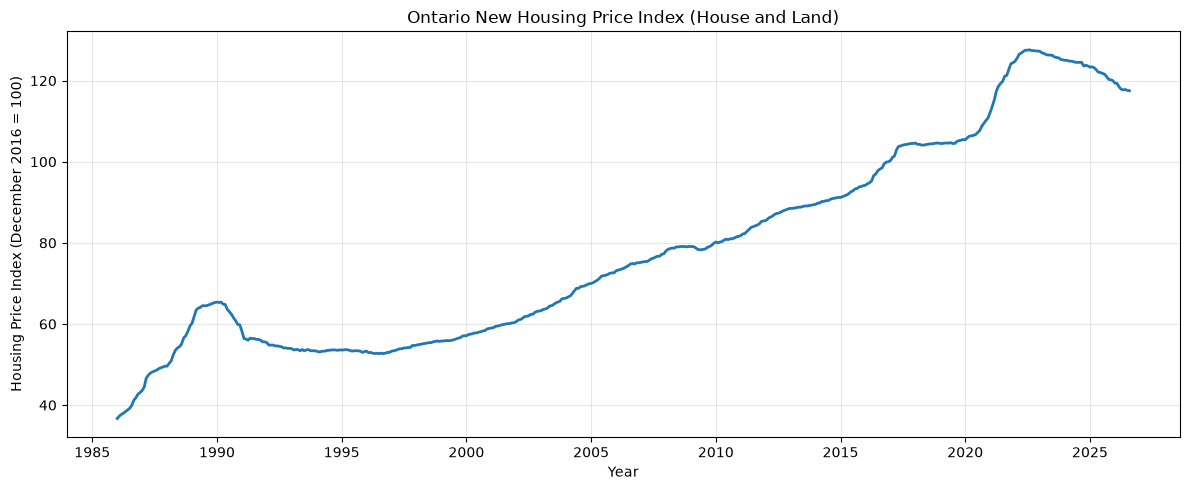

In [171]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    ontario_clean["date"],
    ontario_clean["housing_price_index"],
    linewidth=2
)

plt.title("Ontario New Housing Price Index (House and Land)")
plt.xlabel("Year")
plt.ylabel("Housing Price Index (December 2016 = 100)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ontario Housing Data — Relational Database

After downloading and cleaning the Ontario housing data from the Statistics
Canada API, the processed dataset is stored in Neon PostgreSQL.

This demonstrates the relational database component of our data-sourcing
workflow and allows the data to be retrieved through SQL queries.

In [172]:
# Store the cleaned Ontario dataset in Neon PostgreSQL

ontario_clean.to_sql(
    name="ontario_housing",
    con=engine,
    if_exists="replace",
    index=False
)

print("Ontario housing data successfully uploaded to Neon PostgreSQL.")

Ontario housing data successfully uploaded to Neon PostgreSQL.


### I Checked my Neon Database and the Table with data is created there , also i want ti verifi and show it here for my Assignment purpose to show and verfy the data

In [173]:
from sqlalchemy import text

# Query the Ontario housing table

query = text("""
    SELECT *
    FROM ontario_housing
    ORDER BY date
    LIMIT 5;
""")

with engine.connect() as connection:
    ontario_from_db = pd.read_sql_query(query, connection)

ontario_from_db

,date,province,index_type,unit,housing_price_index
0,1986-01-01,Ontario,Total (house and land),"Index, 201612=100",36.7
1,1986-02-01,Ontario,Total (house and land),"Index, 201612=100",37.3
2,1986-03-01,Ontario,Total (house and land),"Index, 201612=100",37.7
3,1986-04-01,Ontario,Total (house and land),"Index, 201612=100",38.0
4,1986-05-01,Ontario,Total (house and land),"Index, 201612=100",38.4


### Also Verify the record count

In [174]:
# Confirm the database contains all processed Ontario records

count_query = text("""
    SELECT COUNT(*) AS total_records
    FROM ontario_housing;
""")

with engine.connect() as connection:
    ontario_db_count = pd.read_sql_query(count_query, connection)

ontario_db_count

,total_records
0,488



## California Housing — Exploratory Data Analysis

The California Housing Dataset will be used for the univariate linear regression experiment.

Our research question is:

**Can median income predict the median house value in California census block groups?**

For this experiment:

- Predictor (X): `MedInc` — median income
- Target (y): `MedHouseVal` — median house value

We will examine the data structure, summary statistics, missing values, and the relationship between these two variables before preparing the training and testing datasets.


In [175]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the previously saved California housing CSV
california_df = pd.read_csv(
    "../data/raw/california_housing.csv"
)

print("California dataset shape:", california_df.shape)

california_df.head()


California dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [176]:

# Check the data types and structure
california_df.info()

# Check missing values
print("\nMissing values:")
print(california_df.isnull().sum())

# Check duplicate rows (inspection only)
print("\nDuplicate rows:", california_df.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Duplicate rows: 0


### Generate summary statistics

Descriptive statistics help us understand the distribution, central tendency, and range of the numerical housing variables.

In [177]:

# Summary statistics for all numerical columns
california_df.describe().round(2)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [178]:

# Inspect our selected predictor and target
california_df[["MedInc", "MedHouseVal"]].describe().round(2)


,MedInc,MedHouseVal
count,20640.00,20640.00
mean,3.87,2.07
std,1.90,1.15
min,0.50,0.15
25%,2.56,1.20
50%,3.53,1.80
75%,4.74,2.65
max,15.00,5.00


### Lets Visualize median income

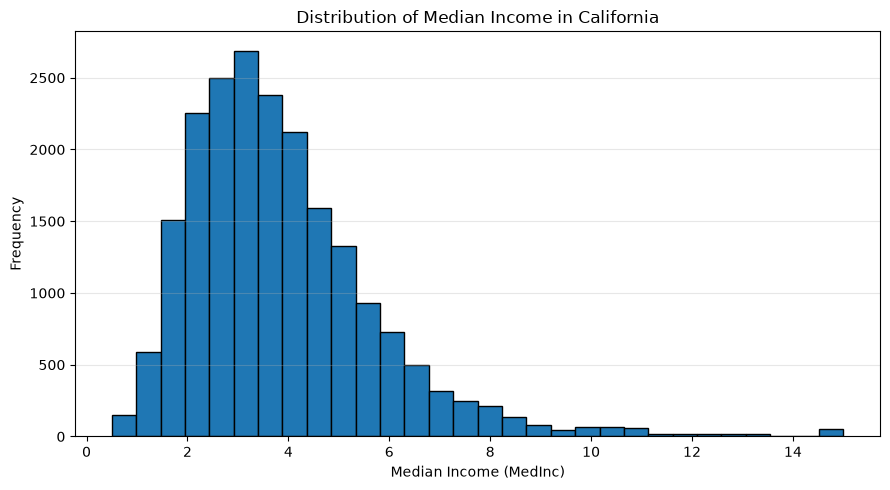

In [179]:

plt.figure(figsize=(9, 5))

plt.hist(
    california_df["MedInc"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Median Income in California")
plt.xlabel("Median Income (MedInc)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Now Visualize median house values

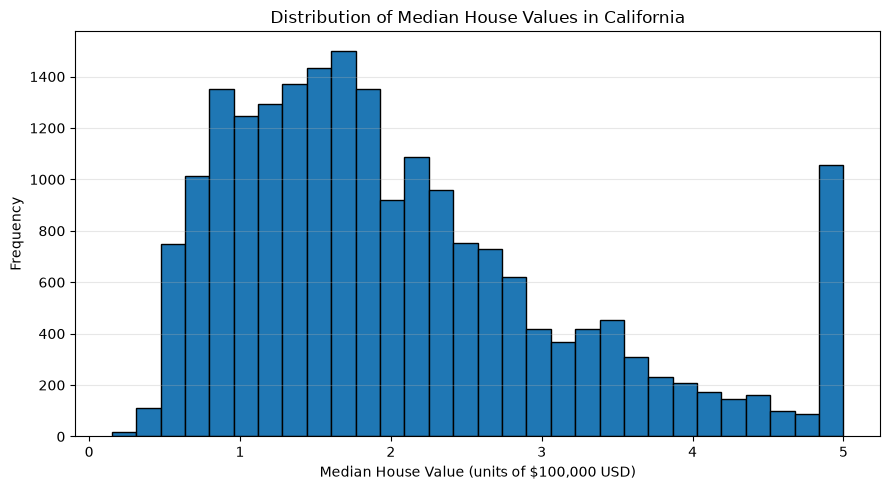

In [180]:

plt.figure(figsize=(9, 5))

plt.hist(
    california_df["MedHouseVal"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Median House Values in California")
plt.xlabel("Median House Value (units of $100,000 USD)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



### Relationship Between Median Income and House Value

A scatter plot helps us examine whether median income and median house value appear to have a linear relationship.

We use a reproducible random sample of 2,000 observations for easier visualization. The complete dataset remains available for model training.


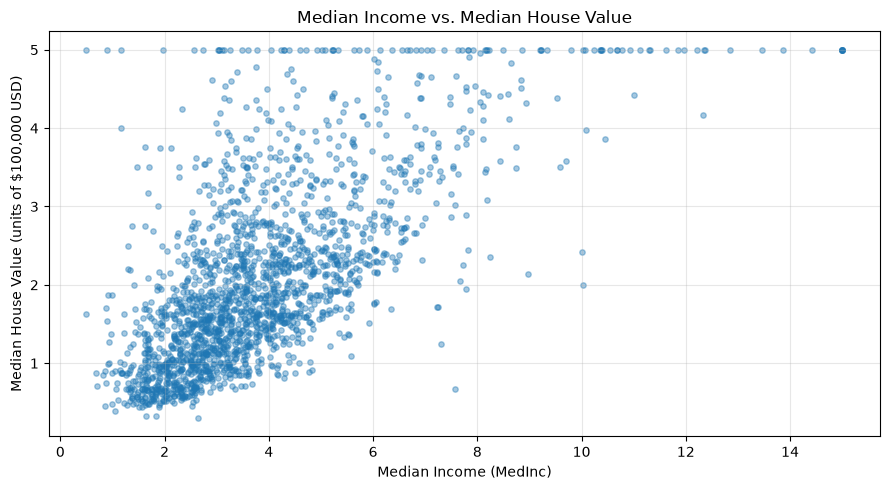

In [181]:

# Use a sample for a clearer scatter plot
california_sample = california_df.sample(
    n=2000,
    random_state=42
)

plt.figure(figsize=(9, 5))

plt.scatter(
    california_sample["MedInc"],
    california_sample["MedHouseVal"],
    alpha=0.4,
    s=15
)

plt.title("Median Income vs. Median House Value")
plt.xlabel("Median Income (MedInc)")
plt.ylabel("Median House Value (units of $100,000 USD)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### We are not drawing a regression line yet. That belongs in linear_regression.ipynb, after implementing and training the model.

In [182]:

# Calculate the correlation between our predictor and target

correlation = california_df[
    ["MedInc", "MedHouseVal"]
].corr()

print("Correlation matrix:")
display(correlation)

print(
    "\nCorrelation between median income and house value:",
    round(correlation.loc["MedInc", "MedHouseVal"], 4)
)


Correlation matrix:


,MedInc,MedHouseVal
MedInc,1.000000,0.688075
MedHouseVal,0.688075,1.000000



Correlation between median income and house value: 0.6881



## Key Findings and Conclusion

The California Housing Dataset contains 20,640 observations and nine numerical columns, with no missing values or duplicate rows.

The analysis shows a positive correlation of **0.6881** between median income (`MedInc`) and median house value (`MedHouseVal`). The scatter plot suggests that higher-income areas generally have higher median house values. However, the target variable is capped at approximately $500,000, which is a limitation of this historical dataset.

For Ontario, we collected real housing price index data through the Statistics Canada API, cleaned the combined house-and-land series, and retained 488 valid monthly observations. We also successfully stored and retrieved both housing datasets using Neon PostgreSQL.

**Modelling decision:** We will use California's `MedInc` as the single predictor and `MedHouseVal` as the target for univariate linear regression. We will compare a gradient descent implementation built from scratch with scikit-learn's LinearRegression model.
